In [ ]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd

data = pd.read_csv('Iris.csv')

X = data.drop(columns=['Species'])  # Assuming 'Species' is the target column
y = data['Species']  # Target (last column)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)
# Train the model
knn.fit(X_train, y_train)
# Make predictions

# y_pred -> ans given by the model
y_pred = knn.predict(X_test) # Model will only receive features

# Evaluate the model -> Compare actual ans with pred
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 100.00%

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


KNN on Wine_dataset 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# Load the Wine dataset
wine_df = pd.read_csv('wine_dataset.csv')  # Make sure this file exists and includes a 'target' column

# Separate features and target
X = wine_df.drop(columns=['target'])
y = wine_df['target']

# Apply MinMax Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=15)  # You can tune this value later
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
acc = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {acc:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 94.44

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.86      0.92        21
           2       0.88      1.00      0.93        14

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54


Confusion Matrix:
 [[19  0  0]
 [ 1 18  2]
 [ 0  0 14]]


on wine dataset 2 with k_best

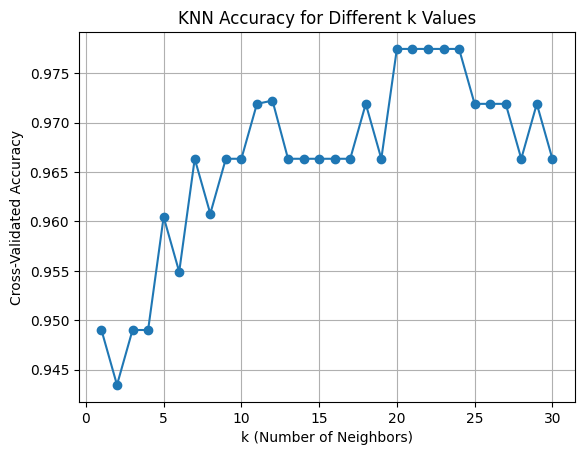


Test Accuracy with k=20: 96.30%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54


Confusion Matrix:
 [[19  0  0]
 [ 1 19  1]
 [ 0  0 14]]


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
wine_df = pd.read_csv('wine_dataset.csv')  # Ensure 'target' is the label column
# [1 2 3 4 5 6 7 8 9 10]
#  |  |_______________| 
#  test     train.     
# Separate features and target
X = wine_df.drop(columns=['target'])
y = wine_df['target']

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X) 

# Find the best k using cross-validation
# k_range = [1  2  3   4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 .]
          #  0  1... . . . . . . . . . . . . . . . . . . . . . . .19
# cv_scores=[94,95,94.5 ,,,,,,, ,,,,,,,,                         97]
#             0  1.....   . . . . . . . . . . . . . . . . . . . . .19         
k_range = range(1, 31)

cv_scores = []
# Value of k = 2

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean()) # X_scaled -> Features

# Plot accuracy vs k
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.grid()
plt.show()

# Find the maximum accuracy
best_score = max(cv_scores) # max score = 97

# Find the index of that maximum accuracy
best_index = cv_scores.index(best_score) # best index =19

# Use that index to get the corresponding k
best_k = k_range[best_index] # kbest is 20


# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train final model with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn_best.predict(X_test)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\nTest Accuracy with k={best_k}: {acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


knn on diabetes 

In [ ]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
from sklearn.preprocessing import scale

# # Load the dataset 
# path = "diabetes.csv"
# names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
# data = pd.read_csv(path, names=names)
# X = data.drop(columns=['class'])  # Assuming 'class' is the target column
# y = data['class']  # Target (last column)

data = pd.read_csv("diabetes.csv")

# Standardize the data (all columns except the last one, which is the target)
data_standardized = scale(data.iloc[:,:-1])

# Convert to DataFrame and add the target column back
data_standardized = pd.DataFrame(data_standardized).round(2)
data_standardized['class'] = data.iloc[:, -1].values  # Add the target column back

X = data_standardized.drop(columns=['class'])  # Assuming 'class' is the target column
y = data_standardized['class']  # Target (last column)


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=17)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 77.06%

Confusion Matrix:
 [[140  11]
 [ 42  38]]


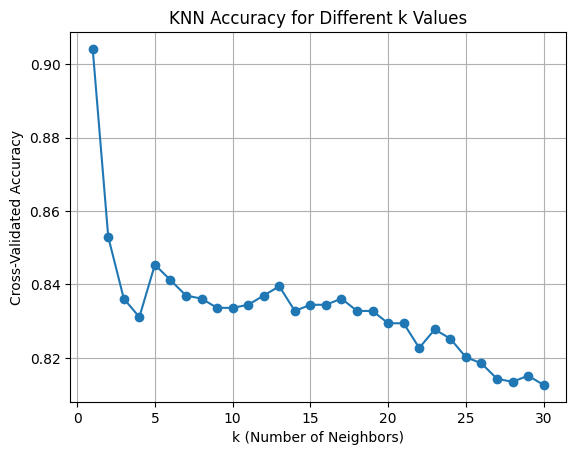


Test Accuracy with k=1: 87.68%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86       154
           1       0.92      0.86      0.89       203

    accuracy                           0.88       357
   macro avg       0.87      0.88      0.88       357
weighted avg       0.88      0.88      0.88       357


Confusion Matrix:
 [[139  15]
 [ 29 174]]


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
wine_df = pd.read_csv('heart_final.csv')  # Ensure 'target' is the label column

# Separate features and target
X = wine_df.drop(columns=['target'])
y = wine_df['target']

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Find the best k using cross-validation
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs k
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.grid()
plt.show()

# Find the maximum accuracy
best_score = max(cv_scores)

# Find the index of that maximum accuracy
best_index = cv_scores.index(best_score)

# Use that index to get the corresponding k
best_k = k_range[best_index]


# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train final model with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn_best.predict(X_test)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\nTest Accuracy with k={best_k}: {acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Graph (Cross-Validated Accuracy vs. k)

The y-axis shows cross-validated accuracy.

For k=1, cross-validation gave an accuracy a bit above 0.90 (90%).

Cross-validation usually splits your training set into folds (e.g., 5 or 10) and reports the average accuracy across them. This is often a bit optimistic compared to test accuracy (depending on dataset variance).

Test Accuracy (with k=1)

You separately evaluated on a held-out test set, which gave 87.68%.

This is slightly lower than the cross-validation result, which is completely normal because the test set was never seen during training or validation, so it provides a more realistic estimate of generalization.

KNN for seeds from uci and save the model

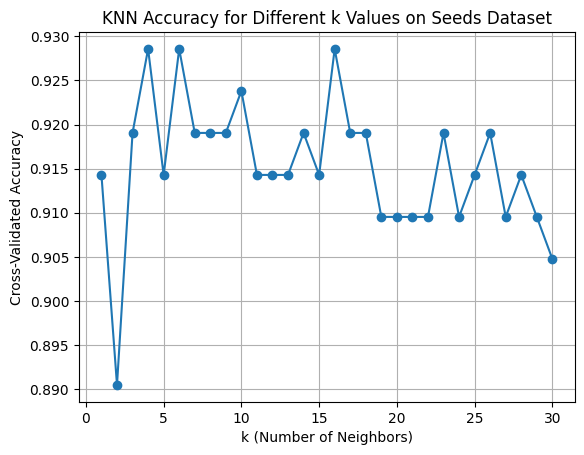


Best Cross-Validated Accuracy: 0.9286
Best k: 4

Test Accuracy with k=4: 92.06%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.88        20
           1       1.00      0.95      0.98        21
           2       0.95      0.86      0.90        22

    accuracy                           0.92        63
   macro avg       0.93      0.92      0.92        63
weighted avg       0.93      0.92      0.92        63


Confusion Matrix:
 [[19  0  1]
 [ 1 20  0]
 [ 3  0 19]]


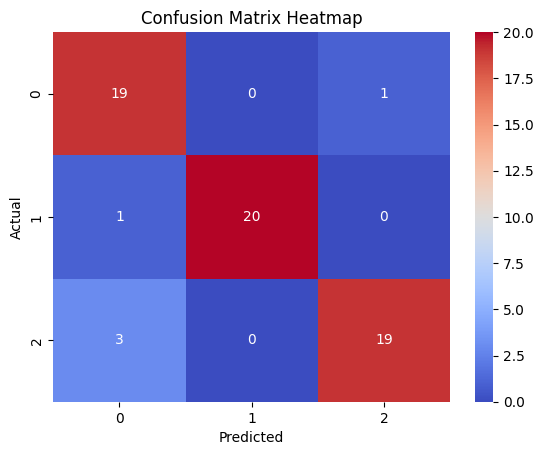

['scaler.pkl']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
# Load UCI Seeds Dataset
# Make sure the CSV has 'target' as the last column
seeds_df = pd.read_csv('seeds_dataset.csv')

# Separate features and target
X = seeds_df.drop(columns=['target'])
y = seeds_df['target']

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Range of k values
k_range = range(1, 31)
cv_scores = []

# Compute CV accuracy for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs k
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy for Different k Values on Seeds Dataset')
plt.grid()
plt.show()

# Retrieve best score and best k
best_score = max(cv_scores)
best_index = cv_scores.index(best_score)
best_k = k_range[best_index]

print(f"\nBest Cross-Validated Accuracy: {best_score:.4f}")
print(f"Best k: {best_k}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Train the model using best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predictions
y_pred = knn_best.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nTest Accuracy with k={best_k}: {acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# HEAT MAP OF A CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


# Save model and scaler to disk
joblib.dump(knn_best, "knn_seeds_model.pkl")
joblib.dump(scaler, "scaler.pkl")


Use saved model

In [2]:
import numpy as np
import joblib

# Load saved model and scaler
knn_loaded = joblib.load("knn_seeds_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

# Example new sample (7 features)
new_sample = np.array([[16.14,14.99,0.9034,5.658,3.562,1.355,5.175]])

# Scale using the SAME scaler used in training
new_sample_scaled = scaler_loaded.transform(new_sample)

# Predict class
prediction = knn_loaded.predict(new_sample_scaled)
print("Predicted Class:", prediction[0])


Predicted Class: 0


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
